# L2 Part A: Bayesian Model Updating
## The Kennedy & O'Hagan Framework for Engineers

---
**file name:** L2_fileA_Bayesian_Model_Updating_Kennedy_OHagan.ipynb

Part of Lecture 2 - first notebook

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---
# Introduction
Engineering models are always **wrong** in the strict sense — they simplify geometry, ignore some physics, and depend on parameters we never measure directly (stiffnesses, damping ratios, contact conditions, material constants). 

A model has a **systematic discrepancy** from reality that must itself be modelled: this is what separates honest engineering UQ from naive curve-fitting.

**Model updating** is the process of using experimental measurements to *learn* those parameters and to *quantify how much we still don't know*.

The **Bayesian** view treats every unknown as a random variable with a probability distribution, and uses **Bayes' theorem** to combine what we believed *before* seeing data (the **prior**) with what the data tell us (the **likelihood**) into an updated belief (the **posterior**). 

The landmark paper with the statistical formulation for calibrating physical/computer models is:

> **Kennedy, M.C. & O'Hagan, A. (2001). "Bayesian calibration of computer models."** *Journal of the Royal Statistical Society, Series B*, **63**(3), 425–464.


---

## Learning outcomes

By the end of this notebook you will be able to:

1. State Bayes' theorem and identify the prior, likelihood, evidence and posterior in an updating problem.
2. Write down the **Kennedy–O'Hagan (KOH) statistical model** and explain each term, especially the **model-discrepancy** function and the observation-error term.
3. Justify the **error-model choices** (why a discrepancy term, why independent Gaussian noise, what ρ does, and the identifiability trap).
4. Place every error term in a **consistent uncertainty taxonomy** — input / model-form / model-parameter / measurement / inherent variability, and aleatory vs epistemic — following Kamariotis et al. (2025).
5. Compute a posterior **three ways**, on physical structural-dynamics examples:
   - **(A) Conjugate priors** — an exact, closed-form update (linear-Gaussian) - we have seen this in L1 already
   - **(B) Laplace / asymptotic approximation** — a Gaussian fit at the posterior mode (nonlinear model).
   - **(C) Markov chain Monte Carlo (MCMC)** — sampling the exact posterior (Metropolis–Hastings).
6. See the KOH discrepancy term *in action* (Section 8), and run a full **SHM-benchmark update** of a nonlinear **Bouc–Wen** hysteretic joint (Section 9).

> **How to use this notebook.** Read the theory cells, then run each code cell in order (`Shift`+`Enter`). Every example is deliberately small enough to run in a second or two and to inspect by hand. Suggested exercises are at the end.


## 1. From forward models to inverse problems

An engineering (or "computer") model is a function
 $$y= \eta(\mathbf{x}, \boldsymbol{\theta}) $$
that predicts an output y

given **control/known inputs** $\mathbf{x}$ (loads, frequencies, positions, temperatures — things we *set* or *measure*) 

and **calibration parameters** $\boldsymbol{\theta}$ (stiffness, damping, modulus — things we *don't* know and want to infer).

- The **forward problem** is: given $\boldsymbol{\theta}$, predict the response. Easy — just run the model.
- The **inverse problem** (model updating / calibration) is: given noisy measurements $\mathbf{z}$ of the real system, infer $\boldsymbol{\theta}$.

This is generally *ill-posed* — many parameter values fit the data almost equally well, and measurement noise means we can never pin $\boldsymbol{\theta}$ down exactly.

The Bayesian answer is not a single "best" $\boldsymbol{\theta}$ but a **posterior distribution** $p(\boldsymbol{\theta}\mid\mathbf{z})$ that expresses the full range of parameter values consistent with the data and our prior knowledge.


## 2. Bayesian inference in one screen

For unknown parameters $\boldsymbol{\theta}$ 

and data $\mathbf{z}$, 

**Bayes' theorem** reads

$$
\underbrace{p(\boldsymbol{\theta}\mid \mathbf{z})}_{\text{posterior}}
=
\frac{
\overbrace{p(\mathbf{z}\mid\boldsymbol{\theta})}^{\text{likelihood}}\;
\overbrace{p(\boldsymbol{\theta})}^{\text{prior}}
}{
\underbrace{p(\mathbf{z})}_{\text{evidence}}
},
\qquad
p(\mathbf{z}) = \int p(\mathbf{z}\mid\boldsymbol{\theta})\,p(\boldsymbol{\theta})\,\mathrm{d}\boldsymbol{\theta}.
$$

| Term | Name | Engineering meaning |
|---|---|---|
| $p(\boldsymbol{\theta})$ | **Prior** | What we believe about $\boldsymbol{\theta}$ before the test (handbook values, tolerances, a previous specimen). |
| $p(\mathbf{z}\mid\boldsymbol{\theta})$ | **Likelihood** | How probable the *measured* data are for a given $\boldsymbol{\theta}$ — this is where the **error model** lives. |
| $p(\boldsymbol{\theta}\mid\mathbf{z})$ | **Posterior** | Updated belief after the test — the deliverable. |
| $p(\mathbf{z})$ | **Evidence** (marginal likelihood) | Normalising constant; also used for **model comparison**. |

Because the evidence is just a constant in $\boldsymbol{\theta}$, we usually work with the **unnormalised posterior**

$$
p(\boldsymbol{\theta}\mid\mathbf{z}) \;\propto\; p(\mathbf{z}\mid\boldsymbol{\theta})\,p(\boldsymbol{\theta}),
$$

and take logs for numerical stability:

$$
\log p(\boldsymbol{\theta}\mid\mathbf{z}) = \text{const} + \log p(\mathbf{z}\mid\boldsymbol{\theta}) + \log p(\boldsymbol{\theta}).
$$

The three methods in this notebook are simply **three ways of dealing with the integral** in the evidence / of summarising the posterior:

- **Conjugate priors** — choose prior + likelihood so the integral is solvable *by hand* (exact).
- **Laplace approximation** — approximate the posterior by a Gaussian at its peak (cheap, asymptotic).
- **MCMC** — draw samples from the posterior without ever computing the integral (general, exact in the limit).


## 3. The Kennedy–O'Hagan (KOH) statistical model

Naive calibration assumes:

the model is *correct* 
only the measurements are noisy. 

This means:
$$ z_i = \eta(\mathbf{x}_i,\boldsymbol{\theta}) + \varepsilon_i. $$

Kennedy & O'Hagan's central point is that this is **dangerous**: 
a model is a simplification, so it has a *systematic* error — a **model discrepancy** (a.k.a. *model inadequacy* / *structural error*) — that does not shrink as you collect more data. Lumping it into $\varepsilon_i$ makes the noise look correlated and biases $\boldsymbol{\theta}$.

Their model of **reality** and of the **observations** is:

$$
\boxed{\;
z_i \;=\; \underbrace{\rho\,\eta(\mathbf{x}_i,\boldsymbol{\theta})}_{\text{calibrated model}}
\;+\; \underbrace{\delta(\mathbf{x}_i)}_{\text{model discrepancy}}
\;+\; \underbrace{\varepsilon_i}_{\text{observation error}}
\;}
\tag{KOH}
$$

with, term by term:

- $\eta(\mathbf{x},\boldsymbol{\theta})$ — the **simulator / physics model** evaluated at the *best* calibration value $\boldsymbol{\theta}$. (If $\eta$ is expensive, KOH replace it by a **Gaussian-process emulator** trained on runs — we skip emulation here and assume $\eta$ is cheap to evaluate.)
- $\rho$ — an optional **scale/regression** factor linking model and reality; often fixed to $\rho=1$.
- $\delta(\mathbf{x})$ — the **discrepancy function**: the systematic, *reproducible* difference between reality and the (scaled) model. KOH model it as a **Gaussian process** $\delta(\cdot)\sim\mathcal{GP}(0,\,k_\delta(\cdot,\cdot))$ — a smooth, zero-mean random function, *independent of* $\eta$.
- $\varepsilon_i$ — **observation error**: independent measurement noise, usually $\varepsilon_i \sim \mathcal{N}(0,\lambda)$ i.i.d.

### 3.1 Why these error-model choices?

**Why a separate discrepancy $\delta$ at all?**
Reality $\zeta(\mathbf{x}) = \rho\,\eta(\mathbf{x},\boldsymbol{\theta}) + \delta(\mathbf{x})$ is not the model. If you omit $\delta$, the optimiser twists $\boldsymbol{\theta}$ into physically wrong values to "absorb" the structural error, and your uncertainty bands become *over-confident*. Including $\delta$ lets the model be wrong in an honest, quantified way.

**Why a Gaussian process for $\delta$?**
The discrepancy is an *unknown smooth function of the inputs*, not a number. A GP is the natural nonparametric prior over smooth functions: it says "$\delta$ is some smooth curve, near zero, with correlation length $\ell$ and amplitude $\sigma_\delta$", without committing to a specific parametric form. The covariance (kernel) encodes our belief about how wrong the model is and how that error varies with $\mathbf{x}$.

**Why independent Gaussian observation noise $\varepsilon$?**
The i.i.d. Gaussian choice is (i) the maximum-entropy distribution given a known variance, (ii) justified by the central-limit-theorem accumulation of many small independent error sources in a sensor chain, and (iii) analytically convenient (it keeps the likelihood Gaussian). If you have replicate measurements you can *estimate* $\lambda$; if the sensor is heteroscedastic or heavy-tailed you would change this choice (e.g. Student-$t$).

**The identifiability trap (read this twice).**
The model $\eta$ and the discrepancy $\delta$ are **confounded**: a change in $\boldsymbol{\theta}$ can often be undone by a change in $\delta(\mathbf{x})$, so the data alone cannot separate them. Consequently:

- The posterior for $\boldsymbol{\theta}$ **depends on the prior/kernel you place on $\delta$** — this never fully "washes out" with more data.
- **Informative priors** on $\boldsymbol{\theta}$ (from physics) and a *sensible* discrepancy kernel are essential.

This point is made forcefully by **Brynjarsdóttir & O'Hagan (2014)**, whose toy example we reproduce in Section 8.

> **Takeaway:** the "error model" is not an afterthought — in KOH it is the modelling. Section 8 shows a case where ignoring $\delta$ gives a confidently *wrong* stiffness, and including it recovers the truth.


### 3.2 Where do these errors live? A consistent uncertainty taxonomy

The KOH decomposition (model $+$ discrepancy $+$ noise) tells us *how* to build the likelihood, but engineers also need a shared vocabulary for *which kind* of uncertainty each term represents. A recent review written specifically for structural dynamics and **structural health monitoring (SHM)** supplies exactly that vocabulary (seen in L1):

> **Kamariotis, A., Vlachas, K., Ntertimanis, V., Koune, I., Cicirello, A. & Chatzi, E. (2025).** *On the consistent classification and treatment of uncertainties in structural health monitoring applications.* ASCE–ASME J. Risk Uncertainty Eng. Syst. Part B: Mech. Eng., **11**(1), 011108. doi:10.1115/1.4067140.

**Top-level split (classical).** Every uncertain quantity is broadly either

- **Aleatory** — irreducible randomness / *inherent variability* (part-to-part scatter, sensor noise, turbulent loading). Richer data only *refine its description*; they never remove it.
- **Epistemic** — reducible *lack of knowledge* (unknown parameters, inadequate model form). More data or a better model *can* shrink it.

The paper stresses that this label is often subjective and context-dependent — e.g. a concrete strength behaves as an *aleatory* variable before the structure is built, but becomes *epistemic* once the finished structure can be tested.

**A finer, five-class taxonomy** (their Sec. 2.6), which we adopt:

| Class | What it covers | Typical nature |
|---|---|---|
| **Input uncertainty** | the excitation/loads $u(t)$ and any submodel of them | aleatory + epistemic |
| **Model-form uncertainty** | the *functional form / structure* of the model $\mathcal{M}$ is simplified or wrong — a.k.a. *model inadequacy* / **model discrepancy** | epistemic |
| **Model parameter/variable uncertainty** | statistical uncertainty in the parameters $\boldsymbol\theta$ (and latent states) *once the form is fixed* | epistemic |
| **Measurement uncertainty** | sensor noise $+$ systematic bias — a.k.a. *observation error* | mostly aleatory |
| **Inherent variability** | slow, irreducible variation in inputs / disturbances / **EOVs** (environmental & operational variability) | aleatory |

**This is the same picture as KOH — now named.** The paper's own Table 1 files *model discrepancy* (the KOH $\delta$) under **model-form uncertainty**, and *observation errors* (the KOH $\varepsilon$) under **measurement uncertainty**. Term by term:

| KOH term (this notebook) | Taxonomy class (Kamariotis et al. 2025) | Reducible? |
|---|---|---|
| model $\eta(\mathbf x,\boldsymbol\theta)$ and its structural error | **model-form uncertainty** | epistemic |
| discrepancy $\delta(\mathbf x)$ (a GP) | **model-form uncertainty** (*model inadequacy*) | epistemic |
| calibration parameters $\boldsymbol\theta$ (the posterior) | **model parameter/variable uncertainty** | epistemic |
| observation noise $\varepsilon_i\sim\mathcal N(0,\lambda)$ | **measurement uncertainty** | aleatory |
| loads / excitation inputs | **input uncertainty** | both |
| specimen-to-specimen & EOV scatter | **inherent variability** | aleatory |

**Why this matters for the likelihood.** *Choosing the error model is choosing which taxonomy classes you admit.* If you fold model-form error into the measurement-noise term, you (i) mislabel an *epistemic, correlated* error as *aleatory, independent* noise, and (ii) obtain the biased, over-confident $\boldsymbol\theta$ we will see in Section 8. Section 9 then puts the full taxonomy to work on the review's own benchmark: a nonlinear hysteretic (Bouc–Wen) structural joint.


## 4. Setup

We use only `numpy`, `scipy`, and `matplotlib`. A fixed random seed makes every result reproducible.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

rng = np.random.default_rng(42)   # single source of randomness -> reproducible

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.30,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11,
    "lines.linewidth": 2.0,
})
np.set_printoptions(precision=4, suppress=True)
print("Environment ready — numpy", np.__version__)

Environment ready — numpy 2.3.5


## 5. Example A — Conjugate priors (exact update)

**When to use it:**

a **linear-Gaussian** model with a Gaussian prior. The posterior is then *also* Gaussian and available in closed form — no integration, no sampling. This is the gold standard when you can get it, and a perfect sanity check for the approximate methods.

**Physical setup — identifying a spring stiffness (Hooke's law).**

We pull a linear spring to a set of known extensions $x_i$ [m] and measure the reaction force $F_i$ [N]. 

The model is
$$ \eta(x,k) = k\,x, \qquad F_i = k\,x_i + \varepsilon_i,\quad \varepsilon_i\sim\mathcal{N}(0,\sigma^2), $$
with **known** noise std $\sigma$ (from the load-cell datasheet / repeat tests). The unknown is the stiffness $k$.

**Conjugate update.** With a Gaussian prior $k\sim\mathcal{N}(m_0,s_0^2)$, the posterior is $k\mid\mathbf{F}\sim\mathcal{N}(m_N,s_N^2)$ with

$$
\frac{1}{s_N^2} = \frac{1}{s_0^2} + \frac{\sum_i x_i^2}{\sigma^2},
\qquad
m_N = s_N^2\!\left(\frac{m_0}{s_0^2} + \frac{\sum_i x_i F_i}{\sigma^2}\right).
$$

Read this as **precision (=1/variance) adds up**: posterior precision = prior precision + data precision, and the posterior mean is a precision-weighted average of the prior mean and the least-squares estimate.


### 5.1.1 Ground truth (unknown to the "analyst") and experiment 

In [19]:
k_true = 2500.0                         # N/m  true stiffness
sigma  = 3.0                            # N    known measurement-noise std
x = np.linspace(0.005, 0.05, 12)        # m    prescribed extensions
F = k_true * x + rng.normal(0, sigma, size=x.size)   # N  measured forces


### 5.1.2 Prior, posterior and their visualization

In [20]:
# --- Prior:  k ~ N(m0, s0^2)  (a handbook guess, deliberately off & broad) ---
m0, s0 = 2000.0, 500.0

def conjugate_update(m0, s0, x, F, sigma):
    prec0 = 1.0 / s0**2                      # prior precision
    precD = np.sum(x**2) / sigma**2          # data precision
    precN = prec0 + precD
    sN = np.sqrt(1.0 / precN)
    mN = sN**2 * (m0 * prec0 + np.sum(x * F) / sigma**2)
    return mN, sN

mN, sN = conjugate_update(m0, s0, x, F, sigma)
print(f"True stiffness      k_true = {k_true:.1f} N/m")
print(f"Prior               k ~ N({m0:.0f}, {s0:.0f}^2)")
print(f"Posterior           k ~ N({mN:.1f}, {sN:.1f}^2)")
print(f"95% credible interval: [{mN-1.96*sN:.1f}, {mN+1.96*sN:.1f}] N/m")

True stiffness      k_true = 2500.0 N/m
Prior               k ~ N(2000, 500^2)
Posterior           k ~ N(2493.1, 28.0^2)
95% credible interval: [2438.3, 2547.9] N/m


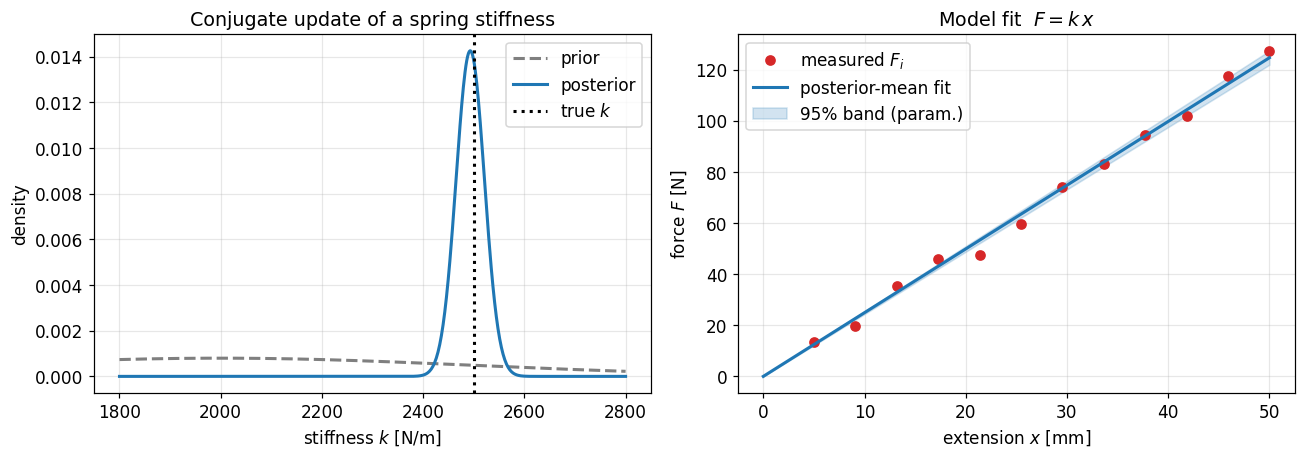

In [21]:
# --- Visualise prior -> posterior, and the data fit -------------------------
kk = np.linspace(1800, 2800, 600)
def gauss(x, m, s): return np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))

ax[0].plot(kk, gauss(kk, m0, s0), '--', color='tab:gray', label='prior')
ax[0].plot(kk, gauss(kk, mN, sN), color='tab:blue', label='posterior')
ax[0].axvline(k_true, color='k', ls=':', label='true $k$')
ax[0].set(xlabel='stiffness $k$ [N/m]', ylabel='density',
          title='Conjugate update of a spring stiffness')
ax[0].legend()

ax[1].plot(x*1e3, F, 'o', color='tab:red', label='measured $F_i$')
xg = np.linspace(0, x.max(), 50)
ax[1].plot(xg*1e3, mN*xg, color='tab:blue', label='posterior-mean fit')
ax[1].fill_between(xg*1e3, (mN-1.96*sN)*xg, (mN+1.96*sN)*xg,
                   color='tab:blue', alpha=0.2, label='95% band (param.)')
ax[1].set(xlabel='extension $x$ [mm]', ylabel='force $F$ [N]',
          title='Model fit  $F=k\,x$')
ax[1].legend()
plt.tight_layout(); plt.show()

### 5.1.3 Sequential (recursive) updating: yesterday's posterior is today's prior, with new data coming in

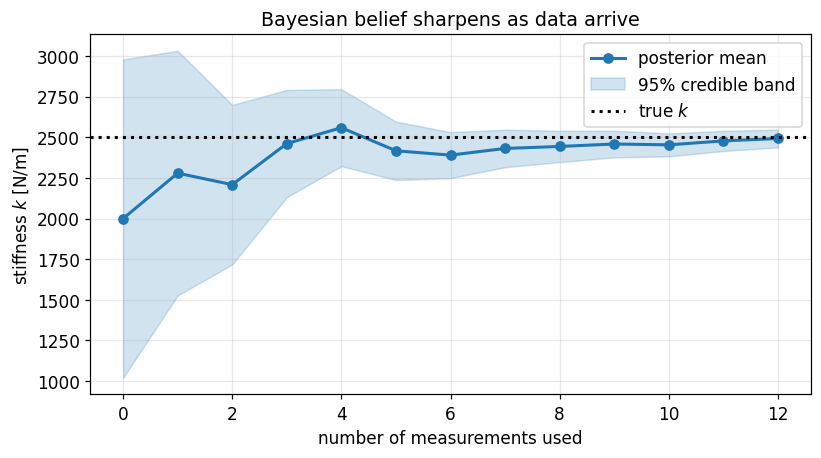

The band narrows and the mean converges on the true value — the essence of updating.


In [22]:
# --- Sequential (recursive) updating: yesterday's posterior is today's prior -
m, s = m0, s0
means, stds = [m], [s]
for i in range(x.size):
    m, s = conjugate_update(m, s, x[i:i+1], F[i:i+1], sigma)   # one point at a time
    means.append(m); stds.append(s)
means, stds = np.array(means), np.array(stds)

fig, ax = plt.subplots(figsize=(7.6, 4.3))
n = np.arange(x.size+1)
ax.plot(n, means, '-o', color='tab:blue', label='posterior mean')
ax.fill_between(n, means-1.96*stds, means+1.96*stds, color='tab:blue', alpha=0.2,
                label='95% credible band')
ax.axhline(k_true, color='k', ls=':', label='true $k$')
ax.set(xlabel='number of measurements used', ylabel='stiffness $k$ [N/m]',
       title='Bayesian belief sharpens as data arrive')
ax.legend(); plt.tight_layout(); plt.show()
print("The band narrows and the mean converges on the true value — the essence of updating.")

**What to notice.** 

The prior was centred at 2000 N/m; 

after 12 measurements the posterior sits tightly around the true 2500 N/m.

Precision *added up*, so the credible interval shrank monotonically. 

This exact result is our reference — the next two methods must reproduce it when the model is linear-Gaussian, and must keep working when it is **not**.

*Aside — unknown noise.* If $\sigma$ is also unknown, the conjugate choice is a **Normal–Inverse-Gamma** prior on $(k,\sigma^2)$, giving a Student-$t$ posterior for $k$. Same idea, one more parameter; we instead let the noise be unknown in Sections 6–7 and handle it numerically.


## 6. Example B — Laplace / asymptotic approximation (nonlinear model)

**When to use it**

Most engineering models are **nonlinear in the parameters**, so the posterior is no longer Gaussian and conjugacy is lost. 

The **Laplace approximation** fits a Gaussian to the posterior at its peak. 

It is the workhorse behind "MAP estimate + covariance from the Hessian" and underlies the **Bayesian Information Criterion (BIC)** and much of classical asymptotic statistics.

**The idea.**

Let $g(\boldsymbol{\theta}) = -\log p(\boldsymbol{\theta}\mid\mathbf{z})$ be the negative log-posterior. 

Taylor-expand it about its minimiser $\hat{\boldsymbol{\theta}}$ (the **MAP** estimate).

The linear term vanishes at the mode, leaving

$$
g(\boldsymbol{\theta}) \approx g(\hat{\boldsymbol{\theta}}) + \tfrac12 (\boldsymbol{\theta}-\hat{\boldsymbol{\theta}})^{\!\top} \mathbf{H}\, (\boldsymbol{\theta}-\hat{\boldsymbol{\theta}}),
\qquad \mathbf{H} = \nabla^2 g(\hat{\boldsymbol{\theta}}),
$$

so the posterior is approximately Gaussian:

$$
\boxed{\; p(\boldsymbol{\theta}\mid\mathbf{z}) \;\approx\; \mathcal{N}\!\big(\hat{\boldsymbol{\theta}},\; \mathbf{H}^{-1}\big). \;}
$$

The inverse Hessian $\mathbf{H}^{-1}$ is the posterior covariance — *curvature = information*. 

As a bonus, the **evidence** follows the same expansion:
$$
\log p(\mathbf{z}) \;\approx\; \log p(\mathbf{z}\mid\hat{\boldsymbol{\theta}}) + \log p(\hat{\boldsymbol{\theta}}) + \tfrac{d}{2}\log 2\pi - \tfrac12\log\det\mathbf{H}.
$$


**Physical setup — stiffness from a measured natural frequency.**

A single-DOF oscillator (mass $m$, stiffness $k$) has natural frequency
$$ \eta(k) = f_n = \frac{1}{2\pi}\sqrt{\frac{k}{m}}\ \text{[Hz]}. $$

We measure $f_n$ a few times (modal test, noisy peak-picking) and infer $k$.

Because $f_n\propto\sqrt{k}$, the map from $f$ to $k$ is nonlinear and the posterior on $k$ is **skewed** — a genuine test for Laplace.


### 6.1.1 Ground truth (unknown to the "analyst") and experiment 

In [23]:
# --- Nonlinear experiment: infer stiffness k from noisy natural frequencies --
m_mass = 1.0                                  # kg (known)
k_true2 = 1000.0                              # N/m (unknown)
f_of_k  = lambda k: np.sqrt(k / m_mass) / (2*np.pi)      # Hz
sig_f   = 0.08                                # Hz measurement noise (known for now)
n_obs   = 4
f_obs   = f_of_k(k_true2) + rng.normal(0, sig_f, size=n_obs)


### 6.1.2 Prior, posterior and their visualization

In [24]:
# Prior on k: broad & biased, N(mu_k, tau_k^2)
mu_k, tau_k = 1300.0, 400.0

def neg_log_post_k(k):
    '''negative log posterior for scalar k (sigma known).'''
    if k <= 0:
        return np.inf
    r  = f_obs - f_of_k(k)
    ll = -0.5*np.sum(r**2)/sig_f**2 - n_obs*np.log(sig_f*np.sqrt(2*np.pi))
    lp = -0.5*(k-mu_k)**2/tau_k**2 - np.log(tau_k*np.sqrt(2*np.pi))
    return -(ll + lp)

# --- MAP estimate -----------------------------------------------------------
res = optimize.minimize_scalar(neg_log_post_k, bounds=(1, 5000), method='bounded')
k_map = res.x

# --- Laplace: variance = 1 / second derivative of neg-log-post at the mode ---
hstep = 1e-3 * k_map
d2 = (neg_log_post_k(k_map+hstep) - 2*neg_log_post_k(k_map) + neg_log_post_k(k_map-hstep)) / hstep**2
sig_lap = np.sqrt(1.0 / d2)
print(f"True k         = {k_true2:.1f} N/m   (f_n = {f_of_k(k_true2):.3f} Hz)")
print(f"MAP estimate   = {k_map:.1f} N/m")
print(f"Laplace std    = {sig_lap:.1f} N/m  ->  95% approx [{k_map-1.96*sig_lap:.0f}, {k_map+1.96*sig_lap:.0f}]")

True k         = 1000.0 N/m   (f_n = 5.033 Hz)
MAP estimate   = 1006.8 N/m
Laplace std    = 15.9 N/m  ->  95% approx [976, 1038]


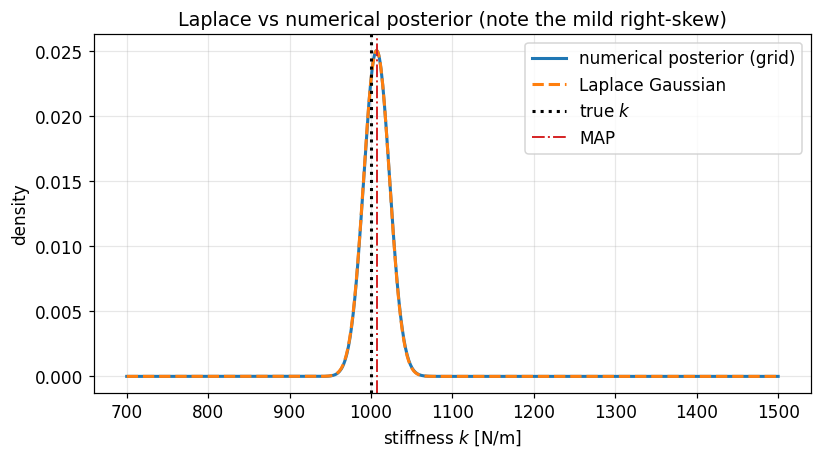

Laplace nails the mode and width but, being symmetric, slightly misses the true skew.


In [25]:
# --- Compare Laplace-Gaussian to the *numerical* posterior on a fine grid (obtained numerically) --------
kg = np.linspace(700, 1500, 800)
logp = np.array([-neg_log_post_k(k) for k in kg])
post_exact = np.exp(logp - logp.max())
post_exact /= np.trapezoid(post_exact, kg)        # normalise numerically
post_lap = gauss(kg, k_map, sig_lap)

fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.plot(kg, post_exact, color='tab:blue', label='numerical posterior (grid)')
ax.plot(kg, post_lap, '--', color='tab:orange', label='Laplace Gaussian')
ax.axvline(k_true2, color='k', ls=':', label='true $k$')
ax.axvline(k_map, color='tab:red', ls='-.', lw=1.3, label='MAP')
ax.set(xlabel='stiffness $k$ [N/m]', ylabel='density',
       title='Laplace vs numerical posterior (note the mild right-skew)')
ax.legend(); plt.tight_layout(); plt.show()
print("Laplace nails the mode and width but, being symmetric, slightly misses the true skew.")

### 6.2 Multivariate Laplace — unknown noise as well

Now treat the noise std $\sigma$ as **unknown** too, so $\boldsymbol{\theta}=(k,\sigma)$.

We work in $(k,\,s)$ with $s=\log\sigma$ so that $\sigma>0$ automatically. 

A cheap and standard trick is to let a quasi-Newton optimiser (**BFGS**) do the work: at convergence it returns an estimate of the **inverse Hessian**, which *is exactly the Laplace covariance*.

Priors: $k\sim\mathcal{N}(\mu_k,\tau_k^2)$ as before, and a weakly-informative **half-Normal** on $\sigma$ (scale $0.2$ Hz). 

Changing variables to $s=\log\sigma$ adds a Jacobian term $+s$ to the log-prior.


In [26]:
scale_sig = 0.20                         # half-Normal scale for sigma [Hz]

def neg_log_post_ks(theta):
    '''negative log posterior for theta=(k, s), s=log(sigma).'''
    k, s = theta
    if k <= 0:
        return np.inf
    sig = np.exp(s)
    r   = f_obs - f_of_k(k)
    ll  = -0.5*np.sum(r**2)/sig**2 - n_obs*(s + 0.5*np.log(2*np.pi))
    lp_k = -0.5*(k-mu_k)**2/tau_k**2
    lp_s = -0.5*sig**2/scale_sig**2 + s      # half-Normal(sigma) + log-Jacobian
    return -(ll + lp_k + lp_s)

x0 = np.array([k_map, np.log(sig_f)])
res2 = optimize.minimize(neg_log_post_ks, x0, method='BFGS')
theta_map = res2.x
cov_lap = res2.hess_inv                  # Laplace covariance in (k, log sigma)

print("MAP:  k = %.1f N/m,  sigma = %.4f Hz" % (theta_map[0], np.exp(theta_map[1])))
print("Laplace covariance (k, log-sigma):\n", cov_lap)
corr = cov_lap[0,1]/np.sqrt(cov_lap[0,0]*cov_lap[1,1])
print(f"Implied k / log-sigma correlation = {corr:+.3f}")

MAP:  k = 1006.7 N/m,  sigma = 0.0653 Hz
Laplace covariance (k, log-sigma):
 [[169.5974   0.1128]
 [  0.1128   0.1537]]
Implied k / log-sigma correlation = +0.022


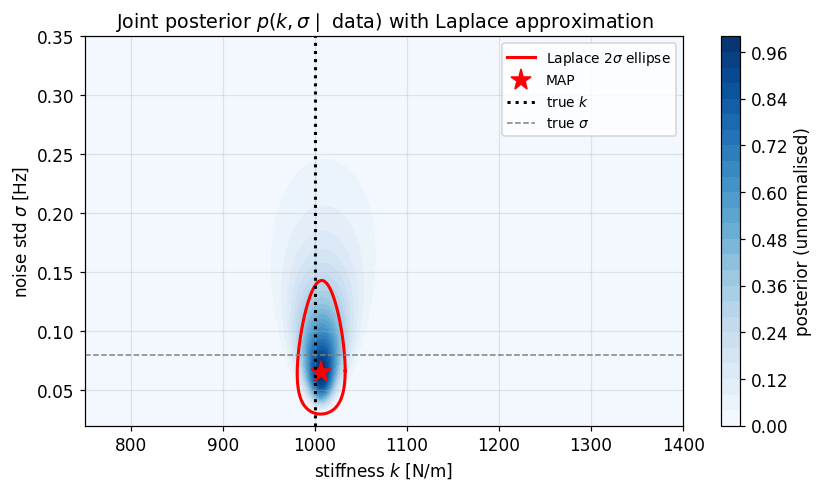

In [27]:
# --- Filled contours of the true joint posterior + Laplace ellipse -----------
kk2 = np.linspace(750, 1400, 220)
ss2 = np.linspace(np.log(0.02), np.log(0.35), 220)
KK, SS = np.meshgrid(kk2, ss2)
Z = np.empty_like(KK)
for i in range(KK.shape[0]):
    for j in range(KK.shape[1]):
        Z[i, j] = -neg_log_post_ks([KK[i, j], SS[i, j]])
Z = np.exp(Z - Z.max())

# 2-sigma Laplace ellipse
th = np.linspace(0, 2*np.pi, 200)
L = np.linalg.cholesky(cov_lap)
ellipse = theta_map[:, None] + 2.0 * L @ np.vstack([np.cos(th), np.sin(th)])

fig, ax = plt.subplots(figsize=(7.8, 4.6))
cs = ax.contourf(KK, np.exp(SS), Z, levels=25, cmap='Blues')
ax.plot(ellipse[0], np.exp(ellipse[1]), 'r-', lw=2, label='Laplace 2$\\sigma$ ellipse')
ax.plot(theta_map[0], np.exp(theta_map[1]), 'r*', ms=14, label='MAP')
ax.axvline(k_true2, color='k', ls=':', label='true $k$')
ax.axhline(sig_f, color='gray', ls='--', lw=1, label='true $\\sigma$')
ax.set(xlabel='stiffness $k$ [N/m]', ylabel='noise std $\\sigma$ [Hz]',
       title='Joint posterior $p(k,\\sigma\\mid$ data$)$ with Laplace approximation')
ax.legend(loc='upper right', fontsize=9)
plt.colorbar(cs, ax=ax, label='posterior (unnormalised)')
plt.tight_layout(); plt.show()

**Strengths & limits of Laplace.** It costs one optimisation and one Hessian — negligibly cheap, and often excellent. 

But it is *local and symmetric*: it cannot see multi-modality, heavy tails, or skew (note how the true $k$–$\sigma$ posterior above is banana-shaped while the ellipse is, well, an ellipse). 

When those features matter, we need samples — enter MCMC.

## 7. Example C — Markov chain Monte Carlo (MCMC)

Most real-world Bayesian models are not conjugate. 

What we *can* always do is compute the **numerator** of Bayes' theorem (likelihood × prior) for any candidate parameter set.
The intractable part is only the evidence, the normalising integral.

$$
\boxed{\;p(\theta\mid\mathbf{z}) \;=\; \frac{p(\mathbf{z}\mid \theta)\,p(\theta)}{p(\mathbf{z})}\;}
$$

$$
\underbrace{p(\theta\mid\mathbf{z})}_{\text{posterior}}\ \propto\
\underbrace{p(\mathbf{z}\mid\theta)}_{\text{likelihood}}\ \times\
\underbrace{p(\theta)}_{\text{prior}},
\qquad
p(\mathbf{z})=\!\int\! p(\mathbf{z}\mid\theta)p(\theta)\,d\theta \;\;(\text{evidence}).
$$

**MCMC** algorithms exploit exactly this: they generate samples whose long-run distribution is the posterior, *using only the un-normalised numerator*. 

The algorithm wanders through parameter space, spending time in each region in proportion to its posterior probability. 
The recipe (the **Metropolis–Hastings** algorithm):

Therefore, MCMC draws a *sequence* of samples $\boldsymbol{\theta}^{(1)},\boldsymbol{\theta}^{(2)},\dots$ whose histogram converges to the exact posterior — **without** computing the evidence integral. 

We only ever need the **unnormalised** posterior. 

Averages of any quantity $h(\boldsymbol{\theta})$ are then just sample means:
$$ \mathbb{E}[h(\boldsymbol{\theta})\mid\mathbf{z}] \approx \frac{1}{N}\sum_{n} h(\boldsymbol{\theta}^{(n)}). $$

### Metropolis–Hastings (the original, 1953/1970)

From the current state $\boldsymbol{\theta}$:
1. **Initialise**: start with a guess for the parameters $(\boldsymbol{\theta})$.
2. **Propose**: perturb the current parameters with a small amount of Gaussian noise. A candidate $\boldsymbol{\theta}^\star \sim q(\cdot\mid\boldsymbol{\theta})$ (here a Gaussian random walk).
3. **Accept or reject**:  Compute the **acceptance ratio** (symmetric proposal ⇒ the $q$'s cancel):
   $$ \alpha = \min\!\left(1,\ \frac{p(\boldsymbol{\theta}^\star\mid\mathbf{z})}{p(\boldsymbol{\theta}\mid\mathbf{z})}\right)
      = \min\!\big(1,\ \exp[\log p^\star - \log p]\big). $$
4. **Accept** $\boldsymbol{\theta}^\star$ with probability $\alpha$, else stay.
If the proposal explains the data better (ratio > 1), always accept it. If it is worse, accept it *with probability equal to the ratio* — this occasional acceptance of worse states is what lets the chain escape local optima and explore the full posterior.
6. **Repeat** thousands of times, building a *chain* of sampled states.

Two practical rules of thumb baked into the code below:
- **Proposal scale.** For a $d$-dimensional target, the optimal random-walk scaling is $\approx 2.4^2/d$ times the target covariance (Roberts–Gelman–Gilks). We use the **Laplace covariance** from Section 6 as that shape — a neat way to reuse work.
- **Burn-in & diagnostics.** Discard an initial segment (the chain must "forget" its start), then check trace plots, acceptance rate ($\sim$0.2–0.5 is healthy), and the **effective sample size (ESS)**.

We sample the *same* $(k,\sigma)$ posterior as Section 6.1, so we can overlay MCMC on the Laplace ellipse and judge the approximation directly.


In [28]:
# --- Metropolis-Hastings on theta = (k, log sigma) --------------------------
def log_post(theta):
    return -neg_log_post_ks(theta)

n_iter, burn = 40000, 8000
prop_cov = (2.4**2 / 2) * cov_lap                 # RGG optimal scaling, d=2
Lp = np.linalg.cholesky(prop_cov)

theta = theta_map.copy()
lp_cur = log_post(theta)
chain = np.empty((n_iter, 2))
n_acc = 0
for i in range(n_iter):
    cand = theta + Lp @ rng.standard_normal(2)
    lp_cand = log_post(cand)
    if np.log(rng.random()) < lp_cand - lp_cur:
        theta, lp_cur = cand, lp_cand
        n_acc += 1
    chain[i] = theta

acc_rate = n_acc / n_iter
post = chain[burn:].copy()
post_k = post[:, 0]
post_sig = np.exp(post[:, 1])
print(f"Acceptance rate = {acc_rate:.2f}   (healthy ~0.2-0.5)")
print(f"Posterior k     : mean {post_k.mean():.1f}, std {post_k.std():.1f} N/m")
print(f"Posterior sigma : mean {post_sig.mean():.4f}, std {post_sig.std():.4f} Hz")

Acceptance rate = 0.41   (healthy ~0.2-0.5)
Posterior k     : mean 1007.3, std 23.3 N/m
Posterior sigma : mean 0.1015, std 0.0564 Hz


In [29]:
# --- Effective sample size (via integrated autocorrelation) -----------------
def ess(x):
    x = x - x.mean()
    n = len(x)
    f = np.fft.fft(x, n=2*n)
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
    acf /= acf[0]
    # sum autocorrelations until they go negative (initial positive sequence)
    tau = 1.0
    for k in range(1, n):
        if acf[k] <= 0:
            break
        tau += 2*acf[k]
    return n / tau

print(f"ESS(k)     = {ess(post_k):8.0f}  of {len(post_k)} samples")
print(f"ESS(sigma) = {ess(post_sig):8.0f}  of {len(post_sig)} samples")

ESS(k)     =     1094  of 32000 samples
ESS(sigma) =     1612  of 32000 samples


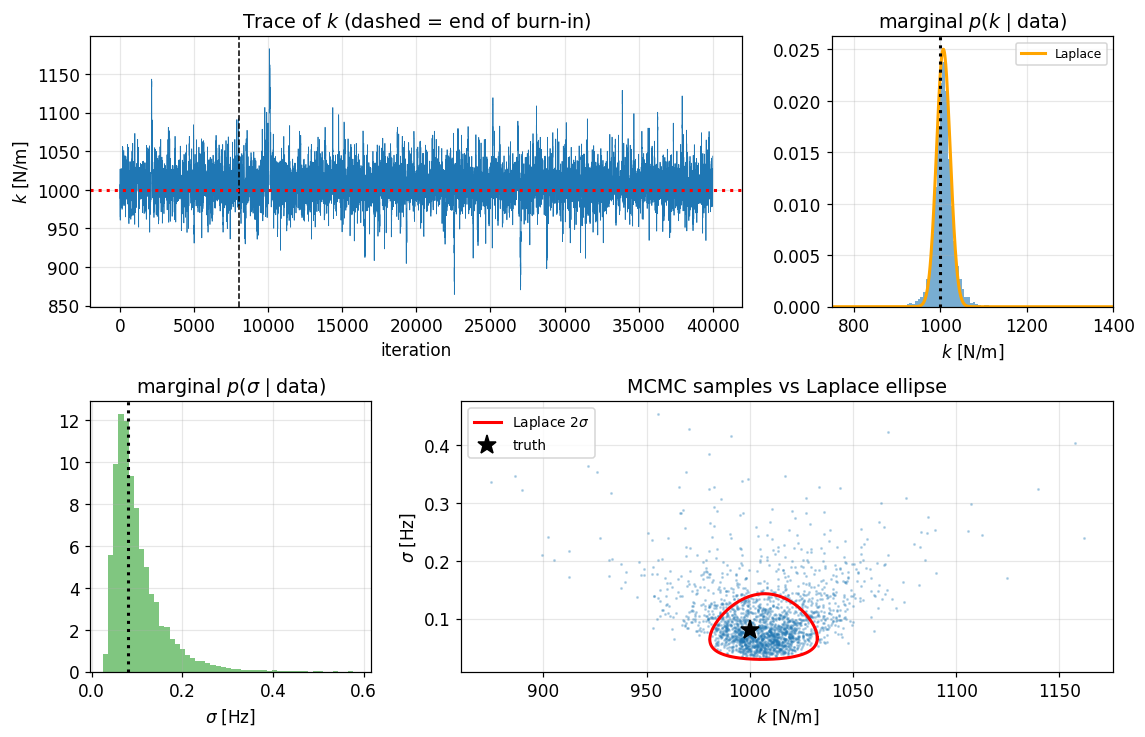

MCMC captures the curved, skewed posterior that the symmetric Laplace ellipse cannot.


In [30]:
# --- Diagnostics: trace, marginals, and joint vs Laplace --------------------
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.32)

axt = fig.add_subplot(gs[0, :2])
axt.plot(chain[:, 0], color='tab:blue', lw=0.5)
axt.axvline(burn, color='k', ls='--', lw=1); axt.axhline(k_true2, color='r', ls=':')
axt.set(title='Trace of $k$ (dashed = end of burn-in)', xlabel='iteration', ylabel='$k$ [N/m]')

axk = fig.add_subplot(gs[0, 2])
axk.hist(post_k, bins=50, density=True, color='tab:blue', alpha=0.6)
axk.plot(kg, gauss(kg, k_map, sig_lap), 'orange', lw=2, label='Laplace')
axk.axvline(k_true2, color='k', ls=':'); axk.set(title='marginal $p(k\\mid$data$)$', xlabel='$k$ [N/m]')
axk.set_xlim(750, 1400); axk.legend(fontsize=8)

axs = fig.add_subplot(gs[1, 0])
axs.hist(post_sig, bins=50, density=True, color='tab:green', alpha=0.6)
axs.axvline(sig_f, color='k', ls=':'); axs.set(title='marginal $p(\\sigma\\mid$data$)$', xlabel='$\\sigma$ [Hz]')

axj = fig.add_subplot(gs[1, 1:])
axj.plot(post_k[::15], post_sig[::15], '.', ms=2, alpha=0.25, color='tab:blue')
axj.plot(ellipse[0], np.exp(ellipse[1]), 'r-', lw=2, label='Laplace 2$\\sigma$')
axj.plot(k_true2, sig_f, 'k*', ms=13, label='truth')
axj.set(title='MCMC samples vs Laplace ellipse', xlabel='$k$ [N/m]', ylabel='$\\sigma$ [Hz]')
axj.legend(fontsize=9)
plt.show()

print("MCMC captures the curved, skewed posterior that the symmetric Laplace ellipse cannot.")

**Reading the diagnostics.**
- The **trace** looks like a "fuzzy caterpillar" with no drift ⇒ the chain is mixing and has converged.
- The **marginal of $k$** shows the mild right-skew (long tail to high stiffness) that Laplace missed.
- The **joint plot** reveals the banana-shaped $k$–$\sigma$ dependence; the Laplace ellipse is a decent but imperfect summary.
- **ESS** ≪ number of iterations because successive samples are correlated — always report ESS, not raw sample count.

MCMC is the most general of the three methods (any prior, any likelihood, any dimension) at the cost of computer time and the need for convergence checks. Modern engines (Hamiltonian Monte Carlo / NUTS in **Stan**, **PyMC**, **NumPyro**; or **emcee**) automate the tuning we did by hand.


## 8. Example D — KOH in action: the model-discrepancy term matters

We now demonstrate the **central lesson of Kennedy & O'Hagan**, using the celebrated toy problem of **Brynjarsdóttir & O'Hagan (2014)**. It shows, unforgettably, that *ignoring the discrepancy term gives a confidently wrong parameter*.

**Reality vs model.** Suppose the true system is
$$ \zeta(x) = \frac{\theta\,x}{1 + x/a}, $$
where $\theta$ is the **physical parameter we care about** (the initial slope, $\zeta'(0)=\theta$) and $a$ controls a *saturation* that our model does not know about. Our **computer model** is the simple linear law
$$ \eta(x,\theta) = \theta\,x. $$
So the model is correct only near $x=0$ and increasingly wrong as $x$ grows — a textbook **model inadequacy**. (Think: a "linear-stiffness" model of a component that actually softens under load.)

We compare two calibrations of $\theta$ from noisy data $z_i=\zeta(x_i)+\varepsilon_i$:

1. **Naive** — assume the model is perfect: $z=\theta x + \varepsilon$. (Exactly the conjugate update of Section 5!)
2. **KOH** — add a Gaussian-process discrepancy: $z=\theta x + \delta(x) + \varepsilon$, with $\delta\sim\mathcal{GP}(0,k_\delta)$.

For a *fixed* GP kernel the KOH posterior for $\theta$ stays Gaussian (generalised least squares with correlated "noise" $\Sigma=\mathbf{K}_\delta+\sigma^2\mathbf{I}$):
$$
\frac{1}{s_N^2}=x^{\!\top}\Sigma^{-1}x+\frac{1}{s_0^2},\qquad
m_N=s_N^2\Big(x^{\!\top}\Sigma^{-1}z+\frac{m_0}{s_0^2}\Big).
$$


In [31]:
# --- Reality, model, and a limited-range experiment -------------------------
theta_true = 0.65          # the physical parameter (initial slope) we want back
a_true     = 6.0           # unknown-to-us saturation constant -> model discrepancy
zeta = lambda x: theta_true * x / (1 + x/a_true)     # reality
eta  = lambda x, th: th * x                          # our (inadequate) linear model

sig_obs = 0.15
xd = np.linspace(1.0, 10.0, 15)                      # design points
z  = zeta(xd) + rng.normal(0, sig_obs, size=xd.size)

# Prior on theta (physics-based, weakly informative): N(0.6, 0.3^2)
m0t, s0t = 0.60, 0.30

# --- (1) NAIVE calibration: no discrepancy (conjugate, Sigma = sigma^2 I) ----
th_naive_m, th_naive_s = conjugate_update(m0t, s0t, xd, z, sig_obs)

# --- (2) KOH calibration: squared-exponential GP discrepancy ----------------
sig_delta, ell = 3.0, 4.0                            # discrepancy amplitude & length-scale (fixed here)
def se_kernel(xa, xb, s, l):
    d = xa[:, None] - xb[None, :]
    return s**2 * np.exp(-0.5*(d/l)**2)

K   = se_kernel(xd, xd, sig_delta, ell)
Sig = K + sig_obs**2 * np.eye(xd.size)               # correlated model+obs error
Sig_inv = np.linalg.inv(Sig)
precN = xd @ Sig_inv @ xd + 1/s0t**2
th_koh_s = np.sqrt(1/precN)
th_koh_m = th_koh_s**2 * (xd @ Sig_inv @ z + m0t/s0t**2)

print(f"TRUE physical parameter theta = {theta_true:.3f}")
print(f"(1) Naive   theta = {th_naive_m:.3f} +/- {th_naive_s:.3f}   <- badly biased AND over-confident")
print(f"(2) KOH+GP  theta = {th_koh_m:.3f} +/- {th_koh_s:.3f}   <- much less biased; wide CI now covers the truth")
lo, hi = th_koh_m-1.96*th_koh_s, th_koh_m+1.96*th_koh_s
print(f"    KOH 95% CI = [{lo:.3f}, {hi:.3f}]  contains true theta={theta_true}?  {lo <= theta_true <= hi}")

TRUE physical parameter theta = 0.650
(1) Naive   theta = 0.290 +/- 0.006   <- badly biased AND over-confident
(2) KOH+GP  theta = 0.409 +/- 0.200   <- much less biased; wide CI now covers the truth
    KOH 95% CI = [0.017, 0.800]  contains true theta=0.65?  True


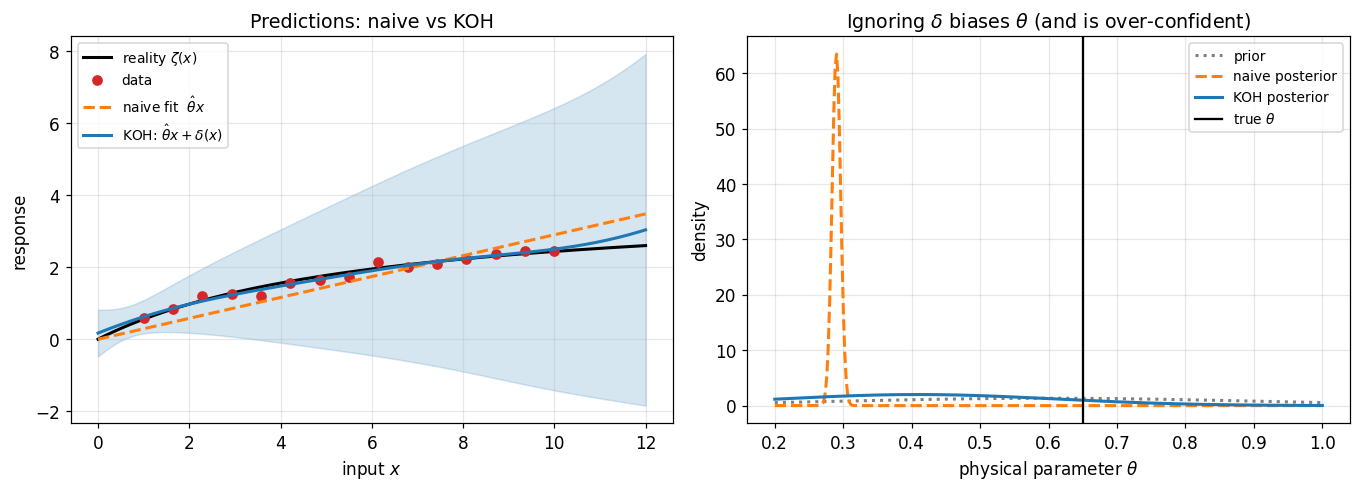

In [32]:
# --- Predictions: naive line vs KOH (model + discrepancy) -------------------
xs = np.linspace(0, 12, 200)

# KOH discrepancy posterior mean (GP regression on residual z - theta*x), at theta_koh_m
resid = z - th_koh_m * xd
Ks = se_kernel(xs, xd, sig_delta, ell)
delta_mean = Ks @ Sig_inv @ resid
# predictive variance of delta (epistemic part of discrepancy)
Kss = se_kernel(xs, xs, sig_delta, ell)
delta_var = np.diag(Kss - Ks @ Sig_inv @ Ks.T)
y_koh = th_koh_m * xs + delta_mean
y_koh_sd = np.sqrt(np.clip(delta_var, 0, None) + (xs*th_koh_s)**2)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax[0].plot(xs, zeta(xs), 'k-', label='reality $\\zeta(x)$')
ax[0].plot(xd, z, 'o', color='tab:red', label='data')
ax[0].plot(xs, th_naive_m*xs, '--', color='tab:orange', label='naive fit  $\\hat\\theta x$')
ax[0].plot(xs, y_koh, '-', color='tab:blue', label='KOH: $\\hat\\theta x+\\delta(x)$')
ax[0].fill_between(xs, y_koh-1.96*y_koh_sd, y_koh+1.96*y_koh_sd, color='tab:blue', alpha=0.18)
ax[0].set(xlabel='input $x$', ylabel='response', title='Predictions: naive vs KOH')
ax[0].legend(fontsize=9)

# posterior densities for theta
tt = np.linspace(0.2, 1.0, 400)
ax[1].plot(tt, gauss(tt, m0t, s0t), ':', color='gray', label='prior')
ax[1].plot(tt, gauss(tt, th_naive_m, th_naive_s), '--', color='tab:orange', label='naive posterior')
ax[1].plot(tt, gauss(tt, th_koh_m, th_koh_s), '-', color='tab:blue', label='KOH posterior')
ax[1].axvline(theta_true, color='k', ls='-', lw=1.5, label='true $\\theta$')
ax[1].set(xlabel='physical parameter $\\theta$', ylabel='density',
          title='Ignoring $\\delta$ biases $\\theta$ (and is over-confident)')
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened — the KOH message in one figure.**

- The **naive** calibration forces a straight line through curved data. To compromise, it *drags $\theta$ away from its true value* (biased) and reports a **tight** interval that does **not** contain the truth (over-confident). More data would only make it more confidently wrong.
- The **KOH** calibration lets the smooth discrepancy $\delta(x)$ soak up the systematic curvature, so $\theta$ is pulled **much closer** to its true value and — crucially — its **honestly wide** credible interval now *covers* the truth (the naive one does not). The prediction also tracks reality across the whole range, not just where data happen to lie. Note the point estimate is still not perfect: with a *fixed, generic* discrepancy kernel the confounding is not fully resolved — which is exactly the next point.

**Caveats you must remember (identifiability).** The KOH result *depends on the discrepancy prior* — here the kernel amplitude $\sigma_\delta$ and length-scale $\ell$, which we fixed. Because $\theta$ and $\delta$ are confounded, different smoothness assumptions give different $\theta$. A full KOH analysis therefore (i) places **informative physical priors** on $\theta$, (ii) **estimates** the GP hyperparameters (often by MCMC alongside $\theta$), and (iii) uses replicate data or multiple experiments to help separate the two. This is precisely the lesson of Brynjarsdóttir & O'Hagan: *you cannot learn the physical parameter well without thinking hard about the discrepancy.*

> **Exercises.** (i) Set `sig_delta = 0` (no discrepancy allowed) and confirm the KOH result collapses back onto the naive one. (ii) Vary `ell` and `sig_delta` and watch $\theta$ move — a hands-on feel for non-identifiability. (iii) Encode the *physical* knowledge that the model is exact at the origin, $\delta(0)=0$, by swapping the squared-exponential for a Wiener kernel $k_\delta(x,x')=\sigma_\delta^2\min(x,x')$; anchoring the discrepancy at the origin tightens the near-origin slope and further reduces the bias in $\theta$.


## 9. Bringing it together — Bayesian updating of a hysteretic link (SHM benchmark)

We close with a compact version of the **running example** from Kamariotis et al. (2025): Bayesian model updating of a **nonlinear hysteretic joint** modelled with the **Bouc–Wen** law. It exercises everything above at once — an MCMC posterior (Section 7), an explicit *measurement-uncertainty* model, and the *model-form vs model-parameter* distinction of the taxonomy (Section 3.2).

**The physical model (their Eqs. 3–4).** Each joint's restoring force splits into a linear and a history-dependent hysteretic part,
$$ R = \underbrace{\alpha\,k\,\Delta u}_{\text{linear}} \;+\; \underbrace{(1-\alpha)\,k\,z}_{\text{hysteretic}}, $$
where $k$ is the joint stiffness, $\alpha\in(0,1)$ is the **post-yield-to-elastic stiffness ratio** (our calibration parameter $\theta$), and the internal hysteretic variable $z$ evolves as
$$ \dot z = A\,\dot u \;-\; \beta\,|\dot u|\,z\,|z|^{w-1} \;-\; \gamma\,\dot u\,|z|^{w}. $$
The shape parameters $(A,\beta,\gamma,w)$ fix the smoothness and amplitude of the hysteresis loop; following the paper we hold them fixed and infer only $\alpha$. A single-degree-of-freedom version under white-noise base excitation is enough to expose the mechanism (the paper uses a two-storey frame with such links).

**The updating problem (their Sec. 4.3).**
- **Prior:** an *uninformative* $\alpha\sim\mathcal U(0.05,\,1.0)$ — pure **model-parameter uncertainty**, no physical steer.
- **Likelihood (their Eq. 14):** built from the discrepancy $g = \tilde{z} - z(\alpha)$ between the *measured* and *model-predicted* acceleration, with $g\sim\mathcal N(\mathbf 0,\mathbf R)$ and a **proportional, diagonal** covariance $\mathbf R = \mathrm{diag}\!\big(c^2\lVert\tilde z\rVert^2\big)$ — the noise std scales with the signal (a % RMS *noise-to-signal* ratio) and is assumed *temporally uncorrelated*. This is an explicit **measurement-uncertainty** choice.
- **Sampler:** the paper uses *transitional MCMC (TMCMC)*; for a single parameter the plain Metropolis sampler of Section 7 is more than enough (and we cross-check with an exact 1-D grid).

**An honest model-form mismatch.** Mirroring the paper — which generates data with a *full-order* model plus a perturbed Young's modulus and then updates a *reduced-order* model — we generate the "measurements" from a truth with $\alpha=0.20$ **and a $+4\%$ stiffness perturbation**, but run the inference with the *nominal* stiffness. That deliberately injected **model-form / parameter uncertainty** is exactly why the posterior below is *non-negligible and slightly shifted* rather than a spike on the true value (compare the paper's Fig. 18).


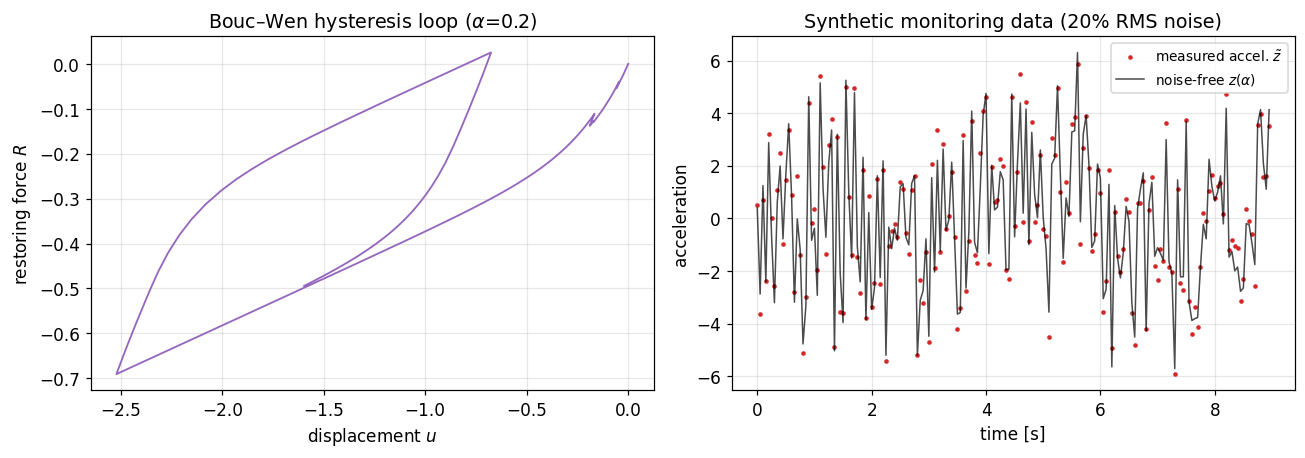

In [33]:
# --- Bouc-Wen single-DOF hysteretic link (nondimensional m=1, nominal k=1) --
zeta_bw, A_bw, beta_bw, gamma_bw, w_bw = 0.04, 1.0, 3.0, 2.0, 1.0   # fixed shape params

def bw_accel(alpha, F, dt, k=1.0, return_states=False):
    '''RK4 integration of a SDOF Bouc-Wen oscillator forced by F[i].
       state = [u (disp), v (vel), z (hysteretic var)]; returns acceleration.'''
    u = v = z = 0.0
    acc = np.empty(len(F)); us = np.empty(len(F)); Rs = np.empty(len(F))
    for i, Fi in enumerate(F):
        def deriv(u, v, z):
            R  = k*(alpha*u + (1-alpha)*z)
            dz = A_bw*v - beta_bw*abs(v)*z*abs(z)**(w_bw-1) - gamma_bw*v*abs(z)**w_bw
            return v, Fi - 2*zeta_bw*v - R, dz            # m=1 -> accel = F - c v - R
        k1 = deriv(u, v, z)
        k2 = deriv(u+0.5*dt*k1[0], v+0.5*dt*k1[1], z+0.5*dt*k1[2])
        k3 = deriv(u+0.5*dt*k2[0], v+0.5*dt*k2[1], z+0.5*dt*k2[2])
        k4 = deriv(u+dt*k3[0],     v+dt*k3[1],     z+dt*k3[2])
        u += dt/6*(k1[0]+2*k2[0]+2*k3[0]+k4[0])
        v += dt/6*(k1[1]+2*k2[1]+2*k3[1]+k4[1])
        z += dt/6*(k1[2]+2*k2[2]+2*k3[2]+k4[2])
        R = k*(alpha*u + (1-alpha)*z)
        acc[i] = Fi - 2*zeta_bw*v - R; us[i] = u; Rs[i] = R
    return (acc, us, Rs) if return_states else acc

# --- synthetic monitoring experiment ---------------------------------------
Nt_bw, dt_bw = 180, 0.05
alpha_true = 0.20
F_bw = 2.5 * rng.standard_normal(Nt_bw)               # white-noise base excitation

# TRUTH: alpha_true AND +4% stiffness (a perturbed-modulus model-form mismatch)
acc_true, u_true, R_true = bw_accel(alpha_true, F_bw, dt_bw, k=1.04, return_states=True)
nsr = 0.20                                            # 20% RMS noise-to-signal
sig_meas = nsr * np.sqrt(np.mean(acc_true**2))
z_meas = acc_true + rng.normal(0, sig_meas, Nt_bw)    # the measured record  d = z~

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(u_true, R_true, color='tab:purple', lw=1.2)
ax[0].set(xlabel='displacement $u$', ylabel='restoring force $R$',
          title=f'Bouc–Wen hysteresis loop ($\\alpha$={alpha_true})')
tt = np.arange(Nt_bw)*dt_bw
ax[1].plot(tt, z_meas, '.', ms=4, color='tab:red', label='measured accel. $\\tilde z$')
ax[1].plot(tt, acc_true, color='k', lw=1.0, alpha=0.7, label='noise-free $z(\\alpha)$')
ax[1].set(xlabel='time [s]', ylabel='acceleration',
          title='Synthetic monitoring data (20% RMS noise)')
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

True alpha        = 0.200   (data carry a +4% stiffness mismatch)
Prior             = U(0.05, 1.0)   (uninformative)
Posterior (grid)  = 0.210 +/- 0.038
Posterior (MCMC)  = 0.208 +/- 0.039   (acc. rate 0.64)


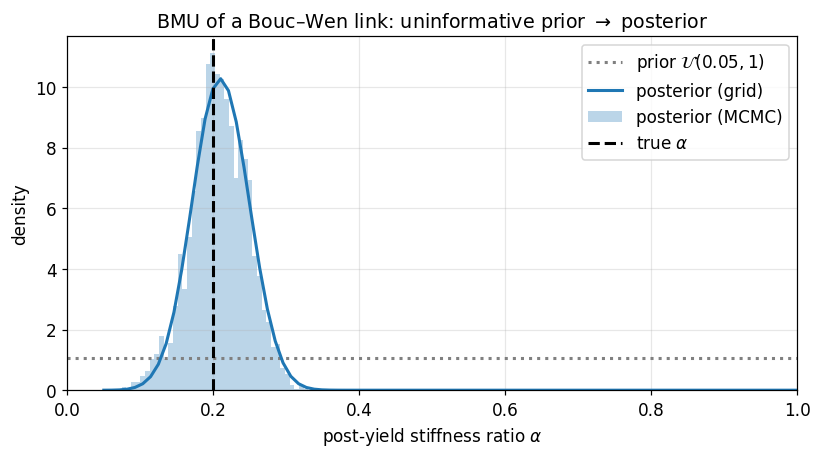

In [34]:
# --- Bayesian model updating of alpha:  prior U(0.05,1.0) + Eq.(14) likelihood
a_lo, a_hi = 0.05, 1.0
var_meas = (nsr**2) * np.sum(z_meas**2) / Nt_bw       # = c^2||z~||^2  (proportional, diagonal)

def log_post_alpha(alpha):
    if not (a_lo <= alpha <= a_hi):                   # uniform-prior support
        return -np.inf
    g = z_meas - bw_accel(alpha, F_bw, dt_bw, k=1.0)  # inference model uses NOMINAL k
    return -0.5*np.sum(g**2)/var_meas                 # flat prior -> log-lik only

# (1) exact 1-D posterior on a grid (alpha is scalar -> cheap & exact) --------
ag = np.linspace(a_lo, a_hi, 90)
lp = np.array([log_post_alpha(a) for a in ag])
post_a = np.exp(lp - lp.max()); post_a /= np.trapezoid(post_a, ag)
a_mean = np.trapezoid(ag*post_a, ag)
a_std  = np.sqrt(np.trapezoid((ag-a_mean)**2*post_a, ag))

# (2) Metropolis MCMC, exactly as in Section 7 ------------------------------
n_mc, burn_mc, step = 4000, 1000, 0.05
a_cur = 0.5; lp_cur = log_post_alpha(a_cur); chain_a = np.empty(n_mc); nacc = 0
for i in range(n_mc):
    cand = a_cur + step*rng.standard_normal()
    lpc = log_post_alpha(cand)
    if np.log(rng.random()) < lpc - lp_cur:
        a_cur, lp_cur = cand, lpc; nacc += 1
    chain_a[i] = a_cur
samp_a = chain_a[burn_mc:]

print(f"True alpha        = {alpha_true:.3f}   (data carry a +4% stiffness mismatch)")
print(f"Prior             = U({a_lo}, {a_hi})   (uninformative)")
print(f"Posterior (grid)  = {a_mean:.3f} +/- {a_std:.3f}")
print(f"Posterior (MCMC)  = {samp_a.mean():.3f} +/- {samp_a.std():.3f}   (acc. rate {nacc/n_mc:.2f})")

fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.axhline(1/(a_hi-a_lo), color='gray', ls=':', label='prior $\\mathcal{U}(0.05,1)$')
ax.plot(ag, post_a, color='tab:blue', lw=2, label='posterior (grid)')
ax.hist(samp_a, bins=40, density=True, color='tab:blue', alpha=0.30, label='posterior (MCMC)')
ax.axvline(alpha_true, color='k', ls='--', label='true $\\alpha$')
ax.set(xlabel=r'post-yield stiffness ratio $\alpha$', ylabel='density', xlim=(0, 1),
       title='BMU of a Bouc–Wen link: uninformative prior $\\to$ posterior')
ax.legend(); plt.tight_layout(); plt.show()

**Reading the result — the taxonomy in action.**

- The **uninformative prior** $\mathcal U(0.05,1)$ (flat: pure *model-parameter uncertainty*) collapses to a **posterior tightly concentrated near the true $\alpha=0.20$** — the data are informative because $\alpha$ governs the *shape* of the hysteresis loop, which the acceleration record sees directly.
- The posterior is **non-negligible and slightly biased high**, not a spike. That residual spread and shift are the fingerprint of the two error classes we injected: **measurement uncertainty** (the 20% proportional noise, via $\mathbf R=\mathrm{diag}(c^2\lVert\tilde z\rVert^2)$) and **model-form / parameter uncertainty** (the $+4\%$ stiffness mismatch between the data-generating and inference models). This is precisely the honest, non-collapsing posterior Kamariotis et al. report (their Fig. 18).
- The **grid** and **Metropolis** posteriors agree — the exact 1-D integral validates the sampler, closing the loop with Section 7.

> **Exercises.** (i) Set the data-generating stiffness back to the nominal `k=1.04 -> 1.0` and watch the bias vanish and the posterior tighten — a clean demonstration that *model-form uncertainty*, not noise, caused the shift. (ii) Lower `nsr` (better sensors) and see *measurement uncertainty* shrink the posterior. (iii) Add a second, correlated noise structure (a non-diagonal $\mathbf R$) and observe how the *error-model choice* changes the inferred $\alpha$ — the likelihood-form decision that Kamariotis et al. file under *model-form uncertainty*.


## 10. Choosing a method — a cheat sheet

| | **Conjugate** | **Laplace** | **MCMC** |
|---|---|---|---|
| Posterior | exact, closed form | Gaussian at the mode | samples (exact in the limit) |
| Model | linear-Gaussian only | any smooth, differentiable | any |
| Cost | trivial | one optimisation + Hessian | many likelihood evals |
| Captures skew / multimodality? | (Gaussian) | no | yes |
| Gives evidence $p(\mathbf z)$? | yes | approx (BIC-like) | with extra work |
| Best for | quick exact checks, priors | fast UQ, good initialisation | the reference answer |

**A pragmatic workflow.** Prototype with a **conjugate** version if you can linearise; get a fast estimate and a proposal covariance from **Laplace**; then run **MCMC** for the trustworthy posterior — using the Laplace covariance to tune the sampler (as we did in Section 7). Always model the **discrepancy** (Section 8) when the physics is approximate, and keep **physical priors informative**.


## 11. References

**Foundational**
1. Kennedy, M.C. & O'Hagan, A. (2001). *Bayesian calibration of computer models.* J. R. Stat. Soc. B, **63**(3), 425–464.
2. Brynjarsdóttir, J. & O'Hagan, A. (2014). *Learning about physical parameters: the importance of model discrepancy.* Inverse Problems, **30**(11), 114007. *(the toy example of Section 8)*
3. Higdon, D., Kennedy, M., Cavendish, J., Cafeo, J. & Ryne, R.D. (2004). *Combining field data and computer simulations for calibration and prediction.* SIAM J. Sci. Comput., **26**(2), 448–466.

**Bayesian computation & theory**
4. Gelman, A., Carlin, J.B., Stern, H.S., Dunson, D.B., Vehtari, A. & Rubin, D.B. (2013). *Bayesian Data Analysis*, 3rd ed. CRC Press. *(Laplace, MCMC, conjugacy)*
5. MacKay, D.J.C. (2003). *Information Theory, Inference, and Learning Algorithms.* Cambridge Univ. Press. *(Laplace approximation, Ch. 27–29)*
6. Metropolis, N. et al. (1953); Hastings, W.K. (1970). *The Metropolis–Hastings algorithm.*
7. Roberts, G.O., Gelman, A. & Gilks, W.R. (1997). *Weak convergence and optimal scaling of random walk Metropolis algorithms.* Ann. Appl. Probab., **7**(1), 110–120. *(the $2.4^2/d$ rule)*

**Uncertainty taxonomy & model updating in structural/earth engineering**
8. Kamariotis, A., Vlachas, K., Ntertimanis, V., Koune, I., Cicirello, A. & Chatzi, E. (2025). *On the consistent classification and treatment of uncertainties in structural health monitoring applications.* ASCE–ASME J. Risk Uncertainty Eng. Syst. Part B: Mech. Eng., **11**(1), 011108. doi:10.1115/1.4067140. *(the 5-class taxonomy of Section 3.2 and the Bouc–Wen benchmark of Section 9)*
9. Beck, J.L. & Katafygiotis, L.S. (1998). *Updating models and their uncertainties. I: Bayesian statistical framework.* J. Eng. Mech., **124**(4), 455–461.
10. Beck, J.L. (2010). *Bayesian system identification based on probability logic.* Struct. Control Health Monit., **17**(7), 825–847.
11. Ching, J. & Chen, Y.-C. (2007). *Transitional Markov chain Monte Carlo method for Bayesian model updating, model class selection, and model averaging.* J. Eng. Mech., **133**(7), 816–832. *(the TMCMC sampler used in the benchmark)*
12. Bouc, R. (1967) & Wen, Y.-K. (1976). *The Bouc–Wen model of smooth hysteresis.* (Proc. 4th Conf. Nonlinear Osc.; J. Eng. Mech. Div. ASCE **102**(2), 249–263.)
13. Rasmussen, C.E. & Williams, C.K.I. (2006). *Gaussian Processes for Machine Learning.* MIT Press. *(the GP prior used for $\delta$)*

**Software (for going beyond hand-rolled MCMC):** Stan, PyMC, NumPyro, `emcee`, GPy / GPyTorch.
